# Applying Fitts' law to Wikispeedia

In [1]:
from DataLoader import DataLoader
from tqdm import tqdm
from sentence_transformers import SentenceTransformer, SimilarityFunction
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy import stats

tqdm.pandas()

In [2]:
dataloader = DataLoader("data")
dataloader.load_paths("paths_finished.tsv")
dataloader.load_edges("links.tsv")
dataloader.paths

,hashedIpAddress,timestamp,durationInSec,path,rating,Goal
0,3824310e536af032,1344753412,88,"[14th_century, Europe, Africa, Atlantic_slave_...",3.0,African_slave_trade
1,415612e93584d30e,1349298640,138,"[14th_century, Niger, Nigeria, British_Empire,...",NaN,African_slave_trade
2,64dd5cd342e3780c,1265613925,37,"[14th_century, Renaissance, Ancient_Greece, Gr...",NaN,Greece
3,015245d773376aab,1366730828,175,"[14th_century, Italy, Roman_Catholic_Church, H...",3.0,John_F._Kennedy
4,5295bca242be81fe,1372890414,110,"[14th_century, Europe, North_America, United_S...",NaN,John_F._Kennedy
...,...,...,...,...,...,...
51312,15a13a1d66ef5456,1349231015,66,"[Yagan, Ancient_Egypt, Civilization]",NaN,Civilization
51313,2ef7ac844cefda58,1300254138,165,"[Yagan, Folklore, Brothers_Grimm, Folklore, 19...",3.0,Fiction
51314,12863abb7887f890,1385095372,228,"[Yagan, Australia, England, France, United_Sta...",NaN,U.S._Open_%28tennis%29
51315,19f8284371753362,1298792567,56,"[Yarralumla%2C_Australian_Capital_Territory, A...",1.0,Abraham_Lincoln


## Embed article titles as distance metric

In [3]:
model = SentenceTransformer("all-MiniLM-L6-v2")
model.similarity_fn_name = SimilarityFunction.EUCLIDEAN

In [4]:
articles = pd.read_csv('data/articles.tsv', sep='\t')

In [5]:
embeddings_array = model.encode(articles['article'], show_progress_bar=True)
embeddings = {}
for i, article in enumerate(articles['article']):
    embeddings[article] = embeddings_array[i]

Batches:   0%|          | 0/144 [00:00<?, ?it/s]

## Load optimal paths

In [6]:
llm_optimal = { k : g.distance.to_dict() for k,g in pd.read_csv("pairs_llm_distances.csv").set_index("source").groupby("target") }

In [7]:
click_optimal = { k : g.distance.to_dict() for k,g in pd.read_csv("pairs_click_distances.csv").set_index("source").groupby("target") }

# Analyze paths

In [8]:
import networkx as nx

edges = pd.read_csv('data/links.tsv', sep='\t', names=['source', 'target'])
edges["distance"] = edges.progress_apply(lambda row: -float(model.similarity(embeddings[row['source']], embeddings[row['target']])[0,0]), axis=1)
edges

G = nx.from_pandas_edgelist(edges, 'source', 'target', edge_attr='distance', create_using=nx.DiGraph())

100%|██████████| 119882/119882 [00:02<00:00, 58222.47it/s]


(array([457., 442., 308., 281., 200., 173., 160., 172., 126., 121., 107.,
         87.,  83.,  86.,  69.,  82.,  68.,  65.,  58.,  51.,  66.,  40.,
         37.,  47.,  37.,  40.,  34.,  32.,  24.,  28.,  27.,  23.,  29.,
         18.,  25.,  19.,  15.,  28.,  20.,  23.,  13.,  17.,  20.,  28.,
         14.,  16.,  13.,  13.,  20.,  12.,  15.,   8.,  11.,  14.,  19.,
         10.,  11.,  10.,   9.,  16.,  13.,   9.,  13.,  13.,   7.,  14.,
          8.,   6.,   9.,   7.,   5.,   7.,  14.,   6.,   5.,   6.,  13.,
          9.,   3.,   8.,   6.,   6.,   3.,   4.,   8.,  11.,   6.,   6.,
          2.,   5.,   4.,   2.,   1.,   4.,   3.,   3.,   1.,   8.,   3.,
          7.]),
 array([ 0.  ,  0.99,  1.98,  2.97,  3.96,  4.95,  5.94,  6.93,  7.92,
         8.91,  9.9 , 10.89, 11.88, 12.87, 13.86, 14.85, 15.84, 16.83,
        17.82, 18.81, 19.8 , 20.79, 21.78, 22.77, 23.76, 24.75, 25.74,
        26.73, 27.72, 28.71, 29.7 , 30.69, 31.68, 32.67, 33.66, 34.65,
        35.64, 36.63, 37.62, 38.61

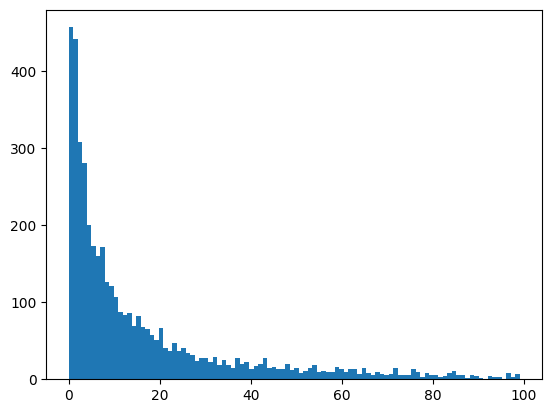

In [9]:
no_in = [G.in_degree(node) for node in G.nodes if G.in_degree(node) < 100]
plt.hist(no_in, bins=100)

In [10]:
def analyze_path(p):
    try:
        path = p['path']
        length = len(path) - 1
        if length < 2:
            # ignore non-games and direct games
            return None
        target_pagerank = dataloader.pagerank[path[-1]] # use pagerank as size
        in_degree = G.in_degree(path[-1])

        llm_distance = -float(model.similarity(embeddings[path[0]], embeddings[path[-1]]))
        # distance = llm_optimal[path[0]][path[-1]]
        llm_opt_distance = llm_optimal[path[-1]][path[0]]
        opt_distance = click_optimal[path[-1]][path[0]]


        llm_difficulty_null = math.log2(llm_distance + 1)
        llm_difficulty = math.log2(llm_distance / target_pagerank + 1)
        llm_difficulty_in_degree = math.log2(llm_distance / in_degree + 1)
        
        llm_opt_difficulty_null = math.log2(llm_opt_distance + 1)
        llm_opt_difficulty = math.log2(llm_opt_distance / target_pagerank + 1)
        llm_opt_difficulty_in_degree = math.log2(llm_opt_distance / in_degree + 1)

        opt_difficulty_null = math.log2(opt_distance + 1)
        opt_difficulty = math.log2(opt_distance / target_pagerank + 1)
        opt_difficulty_in_degree = math.log2(opt_distance / in_degree + 1)

        time = p['durationInSec']
        if time > 600:
            # ignore outliers
            return None
        return pd.Series([path[0], path[-1], 1, time, length,
                          llm_difficulty_null, llm_difficulty, llm_difficulty_in_degree,
                          llm_opt_difficulty_null, llm_opt_difficulty, llm_opt_difficulty_in_degree,
                          opt_difficulty_null, opt_difficulty, opt_difficulty_in_degree,
                          1, math.log2(1.0/target_pagerank + 1), math.log2(1.0/in_degree + 1),
                          llm_distance, llm_opt_distance, opt_distance, target_pagerank, in_degree])
    except KeyError:
        return None


df = dataloader.paths.progress_apply(analyze_path, axis=1).dropna()
df.columns = ["Source", "Target", "Count", "Time", "Length",
              "LLMDifficultyNull", "LLMDifficulty", "LLMDifficultyIndegree",
              "LLMOptDifficultyNull", "LLMOptDifficulty", "LLMOptDifficultyIndegree",
              "OptDifficultyNull", "OptDifficulty", "OptDifficultyIndegree",
              "Null", "NullPageRank", "NullInDegree",
              "LLMDistance", "LLMOptDistance", "OptDistance", "PageRank", "InDegree"]
df

100%|██████████| 51317/51317 [00:06<00:00, 8478.79it/s] 


,Source,Target,Count,Time,Length,LLMDifficultyNull,LLMDifficulty,LLMDifficultyIndegree,LLMOptDifficultyNull,LLMOptDifficulty,...,OptDifficulty,OptDifficultyIndegree,Null,NullPageRank,NullInDegree,LLMDistance,LLMOptDistance,OptDistance,PageRank,InDegree
0,14th_century,African_slave_trade,1.0,88.0,4.0,1.121366,14.796804,0.223957,2.080246,16.254458,...,16.148426,0.514573,1.0,14.563503,0.192645,1.175529,3.228794,3.0,0.000041,7.0
1,14th_century,African_slave_trade,1.0,138.0,7.0,1.121366,14.796804,0.223957,2.080246,16.254458,...,16.148426,0.514573,1.0,14.563503,0.192645,1.175529,3.228794,3.0,0.000041,7.0
2,14th_century,Greece,1.0,37.0,3.0,1.094002,9.415394,0.006639,1.543276,10.169291,...,10.232228,0.011682,1.0,9.233427,0.005853,1.134654,1.914555,2.0,0.001664,246.0
3,14th_century,John_F._Kennedy,1.0,175.0,6.0,1.145528,11.872514,0.028858,2.064520,13.264928,...,13.179536,0.070389,1.0,11.594884,0.023847,1.212270,3.182947,3.0,0.000323,60.0
4,14th_century,John_F._Kennedy,1.0,110.0,5.0,1.145528,11.872514,0.028858,2.064520,13.264928,...,13.179536,0.070389,1.0,11.594884,0.023847,1.212270,3.182947,3.0,0.000323,60.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51312,Yagan,Civilization,1.0,66.0,2.0,1.170798,11.091372,0.030795,1.714323,11.957510,...,11.767625,0.048910,1.0,10.768039,0.024662,1.251362,2.281426,2.0,0.000574,58.0
51313,Yagan,Fiction,1.0,165.0,8.0,1.164619,12.775581,0.056661,1.993589,14.039505,...,14.048059,0.133267,1.0,12.463267,0.045804,1.241741,2.982265,3.0,0.000177,31.0
51314,Yagan,U.S._Open_%28tennis%29,1.0,228.0,6.0,1.199822,13.075030,0.106081,2.094556,14.409333,...,14.284593,0.234465,1.0,12.699775,0.082462,1.297113,3.270948,3.0,0.000150,17.0
51315,Yarralumla%2C_Australian_Capital_Territory,Abraham_Lincoln,1.0,56.0,3.0,1.218183,11.656839,0.030542,1.714532,12.439225,...,12.249025,0.045804,1.0,11.249322,0.023084,1.326535,2.281901,2.0,0.000411,62.0


In [11]:
df_mean = df.groupby(["Source", "Target"]).agg({
    "Count": "sum",
    "Time": "mean",
    "LLMDifficultyNull": "mean",
    "LLMDifficulty": "mean",
    "LLMDifficultyIndegree": "mean",
    "LLMOptDifficultyNull": "mean",
    "LLMOptDifficulty": "mean",
    "LLMOptDifficultyIndegree": "mean",
    "OptDifficultyNull": "mean",
    "OptDifficulty": "mean",
    "OptDifficultyIndegree": "mean",
    "NullPageRank": "mean",
    "NullInDegree": "mean",
    "Length": "mean"
})

df_mean_filtered = df_mean[df_mean["Count"] >= 3]

## Take means of path times and filter by number of occurences

In [12]:
df_mean_filtered.sort_values(by="Count")

Count        Time  LLMDifficultyNull  \
Source      Target                                                       
55_Cancri_c African_Great_Lakes     3.0   66.666667           1.214664   
5th_century Ant                     3.0  170.333333           1.211041   
6th_century Assyria                 3.0  219.666667           1.104649   
AIDS        Cold_War                3.0   96.666667           1.116990   
            Paprika                 3.0  218.000000           1.196316   
...                                 ...         ...                ...   
Batman      Wood                  146.0  101.191781           1.175097   
Pyramid     Bean                  625.0  175.912000           1.198773   
Theatre     Zebra                 877.0  177.328392           1.200467   
Brain       Telephone            1009.0  149.148662           1.114042   
Asteroid    Viking               1010.0  169.034653           1.169396   

                                 LLMDifficulty  LLMDifficultyIndegree  \
Source      Target                                                      
55_Cancri_c African_Great_Lakes      14.341515               0.178984   
5th_century Ant                      12.726928               0.068609   
6th_century Assyria                  12.089710               0.058092   
AIDS        Cold_War                  9.929904               0.010124   
            Paprika                  13.937807               0.127307   
...                                        ...                    ...   
Batman      Wood                     11.752937               0.032629   
Pyramid     Bean                     13.361903               0.105950   
Theatre     Zebra                    13.537707               0.148190   
Brain       Telephone                11.782938               0.038551   
Asteroid    Viking                   10.701863               0.022922   

                                 LLMOptDifficultyNull  LLMOptDifficulty  \
Source      Target                                                        
55_Cancri_c African_Great_Lakes              2.200575         15.786630   
5th_century Ant                              2.157150         14.122592   
6th_century Assyria                          1.754603         13.134846   
AIDS        Cold_War                         1.698154         10.870616   
            Paprika                          2.091255         15.274058   
...                                               ...               ...   
Batman      Wood                             2.156981         13.212137   
Pyramid     Bean                             2.182324         14.811647   
Theatre     Zebra                            2.142273         14.932889   
Brain       Telephone                        2.069776         13.240219   
Asteroid    Viking                           2.058028         12.042190   

                                 LLMOptDifficultyIndegree  OptDifficultyNull  \
Source      Target                                                             
55_Cancri_c African_Great_Lakes                  0.443249           2.321928   
5th_century Ant                                  0.173972           2.000000   
6th_century Assyria                              0.117426           1.584963   
AIDS        Cold_War                             0.019379           1.584963   
            Paprika                              0.302105           2.000000   
...                                                   ...                ...   
Batman      Wood                                 0.088013           2.000000   
Pyramid     Bean                                 0.272820           2.000000   
Theatre     Zebra                                0.361260           2.000000   
Brain       Telephone                            0.103500           2.000000   
Asteroid    Viking                               0.057369           2.000000   

                                 OptDifficulty  OptDifficultyIndegree  \
Source      Target             

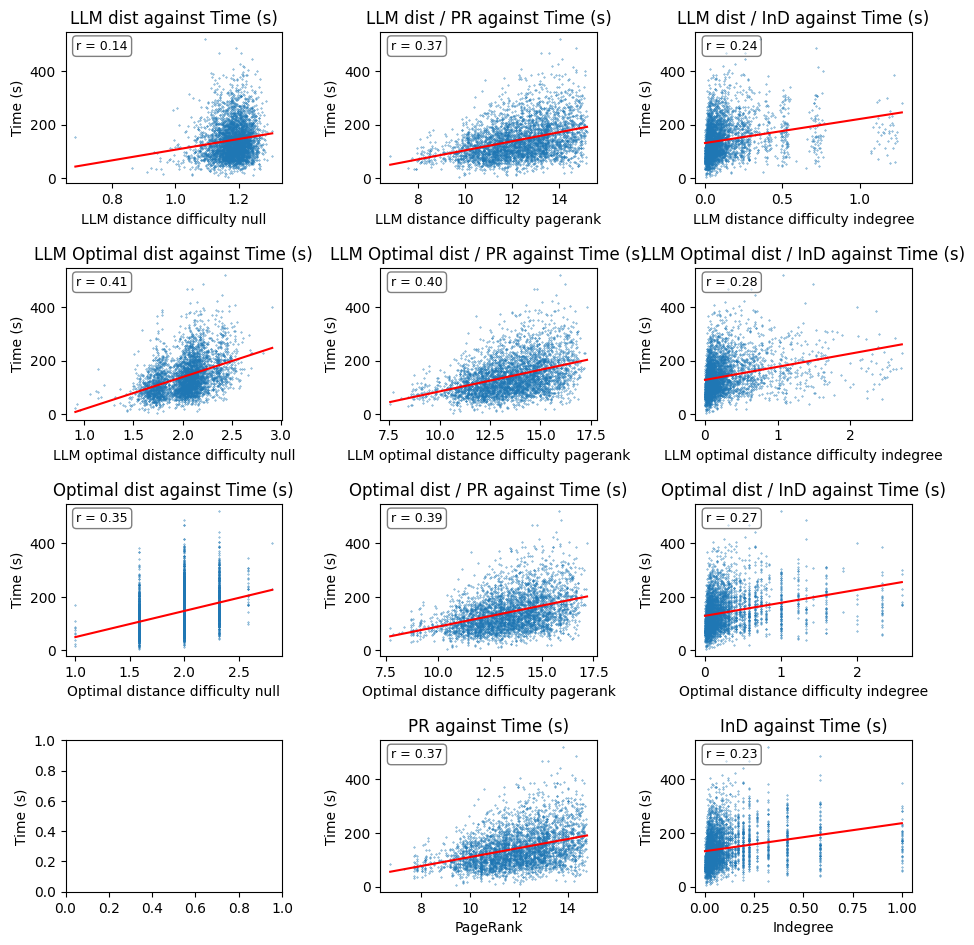

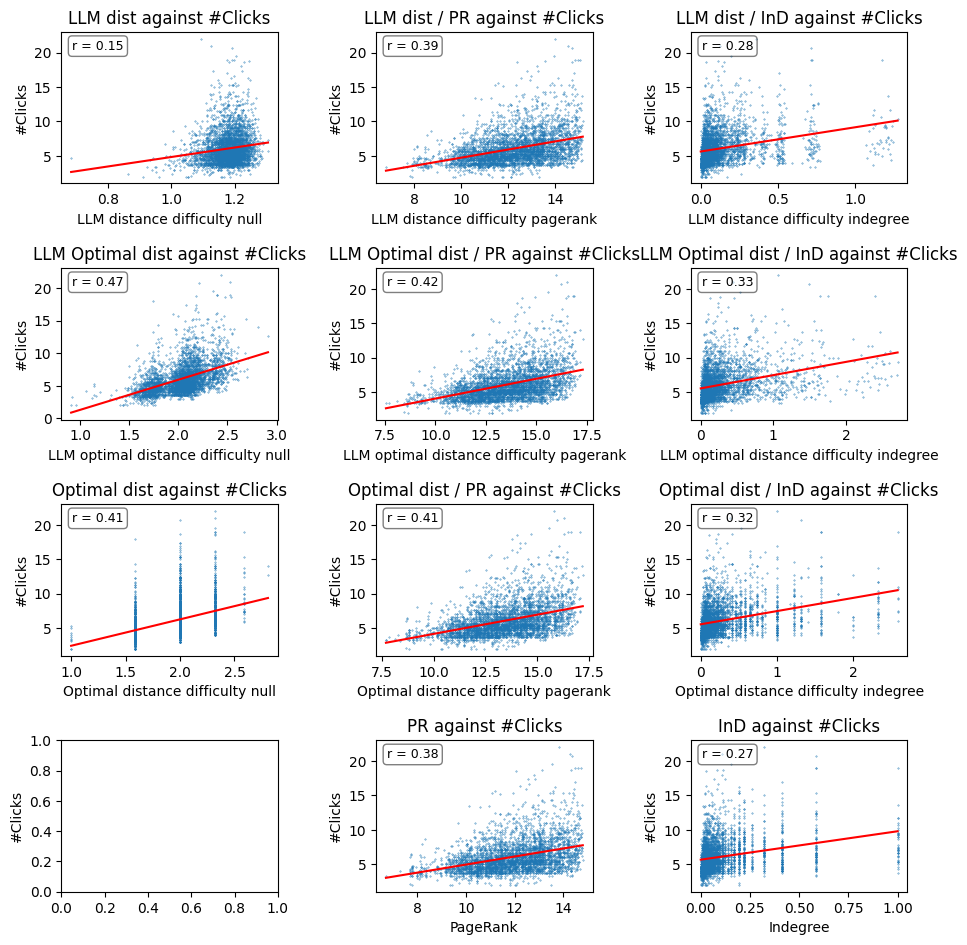

In [ ]:
IDs = ["LLMDifficultyNull", "LLMDifficulty", "LLMDifficultyIndegree",
       "LLMOptDifficultyNull", "LLMOptDifficulty", "LLMOptDifficultyIndegree",
       "OptDifficultyNull", "OptDifficulty", "OptDifficultyIndegree",
       None, "NullPageRank", "NullInDegree"]
x_labels = ["LLM distance difficulty null","LLM distance difficulty pagerank", "LLM distance difficulty indegree",
            "LLM optimal distance difficulty null", "LLM optimal distance difficulty pagerank", "LLM optimal distance difficulty indegree",
            "Optimal distance difficulty null", "Optimal distance difficulty pagerank", "Optimal distance difficulty indegree",
            "Null", "PageRank", "Indegree"]

preds = ["Time", "Length"]
y_labels = ["Time (s)", "#Clicks"]

titles1 = ["LLM dist against", "LLM dist / PR against", "LLM dist / InD against",
           "LLM Optimal dist against", "LLM Optimal dist / PR against", "LLM Optimal dist / InD against",
           "Optimal dist against", "Optimal dist / PR against", "Optimal dist / InD against",
           "Null", "PR against", "InD against"]


final_titles = [f"{titles1[i]} {y_labels[0]}" for i in range(12)] + [f"{titles1[i]} {y_labels[1]}" for i in range(12)]

for z in range(2):
    fig, axs = plt.subplots(4, 3, figsize=(10, 10))
    plt.tight_layout(pad=4.0)  # adds padding between subplots and labels

    for i in range(4):
        for j in range(3):
            if IDs[3*i + j] is None:
                continue
            X = df_mean_filtered[IDs[3*i + j]]
            y = df_mean_filtered[preds[z]]

            slope, intercept, rval, pval, stderr = stats.linregress(X, y)
            axs[i, j].scatter(X, y, s=0.1)
            xs = np.linspace(min(X), max(X))
            ys = slope*xs + intercept

            axs[i, j].text(
                0.05, 0.95,                      # x, y position in axes coordinates
                f"r = {rval:.2f}",               # formatted r-value
                transform=axs[i, j].transAxes,   # interpret coordinates relative to the axes
                fontsize=9,
                verticalalignment='top',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.5)
            )

            axs[i, j].plot(xs, ys, color="red")
            axs[i, j].set_title(final_titles[12 * z + 3*i + j])
            axs[i, j].set_xlabel(x_labels[3*i + j])

    for ax in axs.flat:
        ax.set(ylabel=f'{y_labels[z]}')


In [14]:
df.columns

Index(['Source', 'Target', 'Count', 'Time', 'Length', 'LLMDifficultyNull',
       'LLMDifficulty', 'LLMDifficultyIndegree', 'LLMOptDifficultyNull',
       'LLMOptDifficulty', 'LLMOptDifficultyIndegree', 'OptDifficultyNull',
       'OptDifficulty', 'OptDifficultyIndegree', 'Null', 'NullPageRank',
       'NullInDegree', 'LLMDistance', 'LLMOptDistance', 'OptDistance',
       'PageRank', 'InDegree'],
      dtype='object')

In [15]:
def bin(df, column, n_bins=100):
    df_bin = df
    df_bin["Difficulty"] = df[column]
    df_bin["Bin"] = pd.qcut(df_bin["Difficulty"], q=n_bins, duplicates='drop')
    return df_bin.groupby("Bin").agg({
        "Count": "sum",
        "Difficulty": "mean",
        "Time": "mean",
        "Length": "mean",
    })

bin(df, "OptDifficultyIndegree")

/tmp/ipykernel_694983/4043130989.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return df_bin.groupby("Bin").agg({


,Count,Difficulty,Time,Length
Bin,,,,
"(-6.999999999999997e-05, 0.00503]",504.0,0.003882,61.087302,3.418651
"(0.00503, 0.00801]",484.0,0.006029,72.778926,3.733471
"(0.00801, 0.0105]",498.0,0.009150,74.072289,3.600402
"(0.0105, 0.0135]",490.0,0.012089,79.824490,3.708163
"(0.0135, 0.0157]",546.0,0.014921,78.756410,4.064103
...,...,...,...,...
"(1.222, 1.322]",484.0,1.321928,152.097107,6.064050
"(1.322, 1.585]",662.0,1.566225,196.061934,7.506042
"(1.585, 1.807]",71.0,1.807355,251.704225,10.295775


/tmp/ipykernel_694983/4043130989.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return df_bin.groupby("Bin").agg({
/tmp/ipykernel_694983/4043130989.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return df_bin.groupby("Bin").agg({
/tmp/ipykernel_694983/4043130989.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return df_bin.groupby("Bin").agg({
/tmp/ipykernel_694983/4043130989.py:5: FutureWarning: The defaul

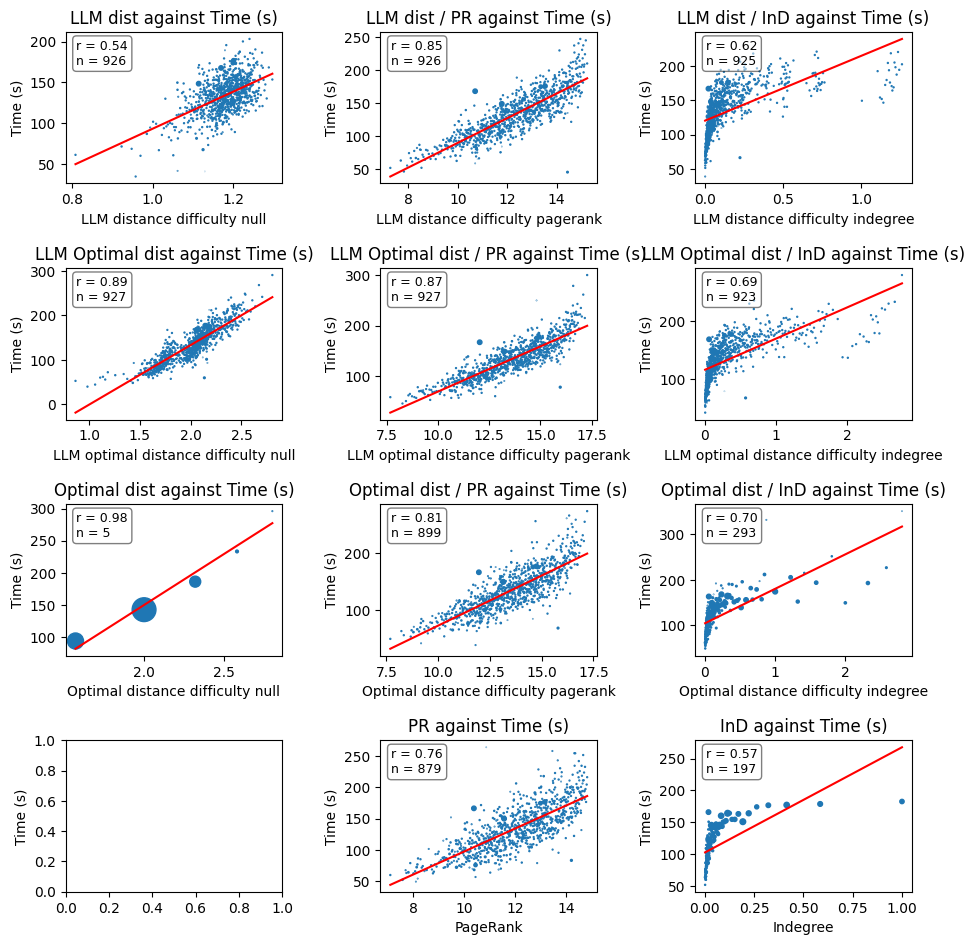

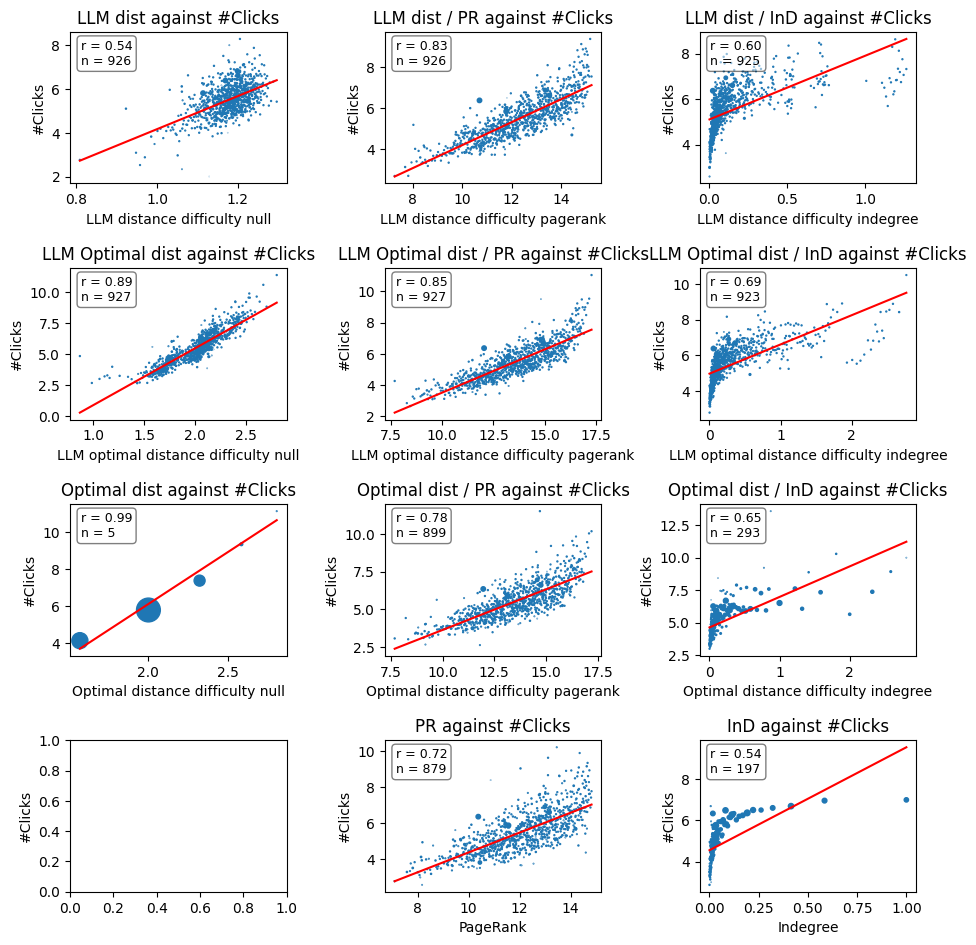

In [16]:
IDs = ["LLMDifficultyNull", "LLMDifficulty", "LLMDifficultyIndegree",
       "LLMOptDifficultyNull", "LLMOptDifficulty", "LLMOptDifficultyIndegree",
       "OptDifficultyNull", "OptDifficulty", "OptDifficultyIndegree",
       None, "NullPageRank", "NullInDegree"]
x_labels = ["LLM distance difficulty null","LLM distance difficulty pagerank", "LLM distance difficulty indegree",
            "LLM optimal distance difficulty null", "LLM optimal distance difficulty pagerank", "LLM optimal distance difficulty indegree",
            "Optimal distance difficulty null", "Optimal distance difficulty pagerank", "Optimal distance difficulty indegree",
            "Null", "PageRank", "Indegree"]

preds = ["Time", "Length"]
y_labels = ["Time (s)", "#Clicks"]

titles1 = ["LLM dist against", "LLM dist / PR against", "LLM dist / InD against",
           "LLM Optimal dist against", "LLM Optimal dist / PR against", "LLM Optimal dist / InD against",
           "Optimal dist against", "Optimal dist / PR against", "Optimal dist / InD against",
           "Null", "PR against", "InD against"]


final_titles = [f"{titles1[i]} {y_labels[0]}" for i in range(12)] + [f"{titles1[i]} {y_labels[1]}" for i in range(12)]

for z in range(2):
    fig, axs = plt.subplots(4, 3, figsize=(10, 10))
    plt.tight_layout(pad=4.0)  # adds padding between subplots and labels

    for i in range(4):
        for j in range(3):
            if IDs[3*i + j] is None:
                continue
            # X = df_mean_filtered[IDs[2*i + j]]
            # y = df_mean_filtered[preds[z]]
            df_bin = bin(df, IDs[3*i + j], n_bins=1000)
            X = df_bin["Difficulty"]
            y = df_bin[preds[z]]
            s = df_bin["Count"]

            slope, intercept, rval, pval, stderr = stats.linregress(X, y, nan_policy="omit")
            axs[i, j].scatter(X, y, s / 100)
            xs = np.linspace(min(X), max(X))
            ys = slope*xs + intercept

            axs[i, j].text(
                0.05, 0.95,                      # x, y position in axes coordinates
                f"r = {rval:.2f}\nn = {len(df_bin)}",               # formatted r-value
                transform=axs[i, j].transAxes,   # interpret coordinates relative to the axes
                fontsize=9,
                verticalalignment='top',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.5)
            )

            axs[i, j].plot(xs, ys, color="red")
            axs[i, j].set_title(final_titles[12 * z + 3*i + j])
            axs[i, j].set_xlabel(x_labels[3*i + j])

    for ax in axs.flat:
        ax.set(ylabel=f'{y_labels[z]}')
